<a href="https://colab.research.google.com/github/ZhannaPavlova/colab/blob/main/chart_3_mckinsey_lever_top.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

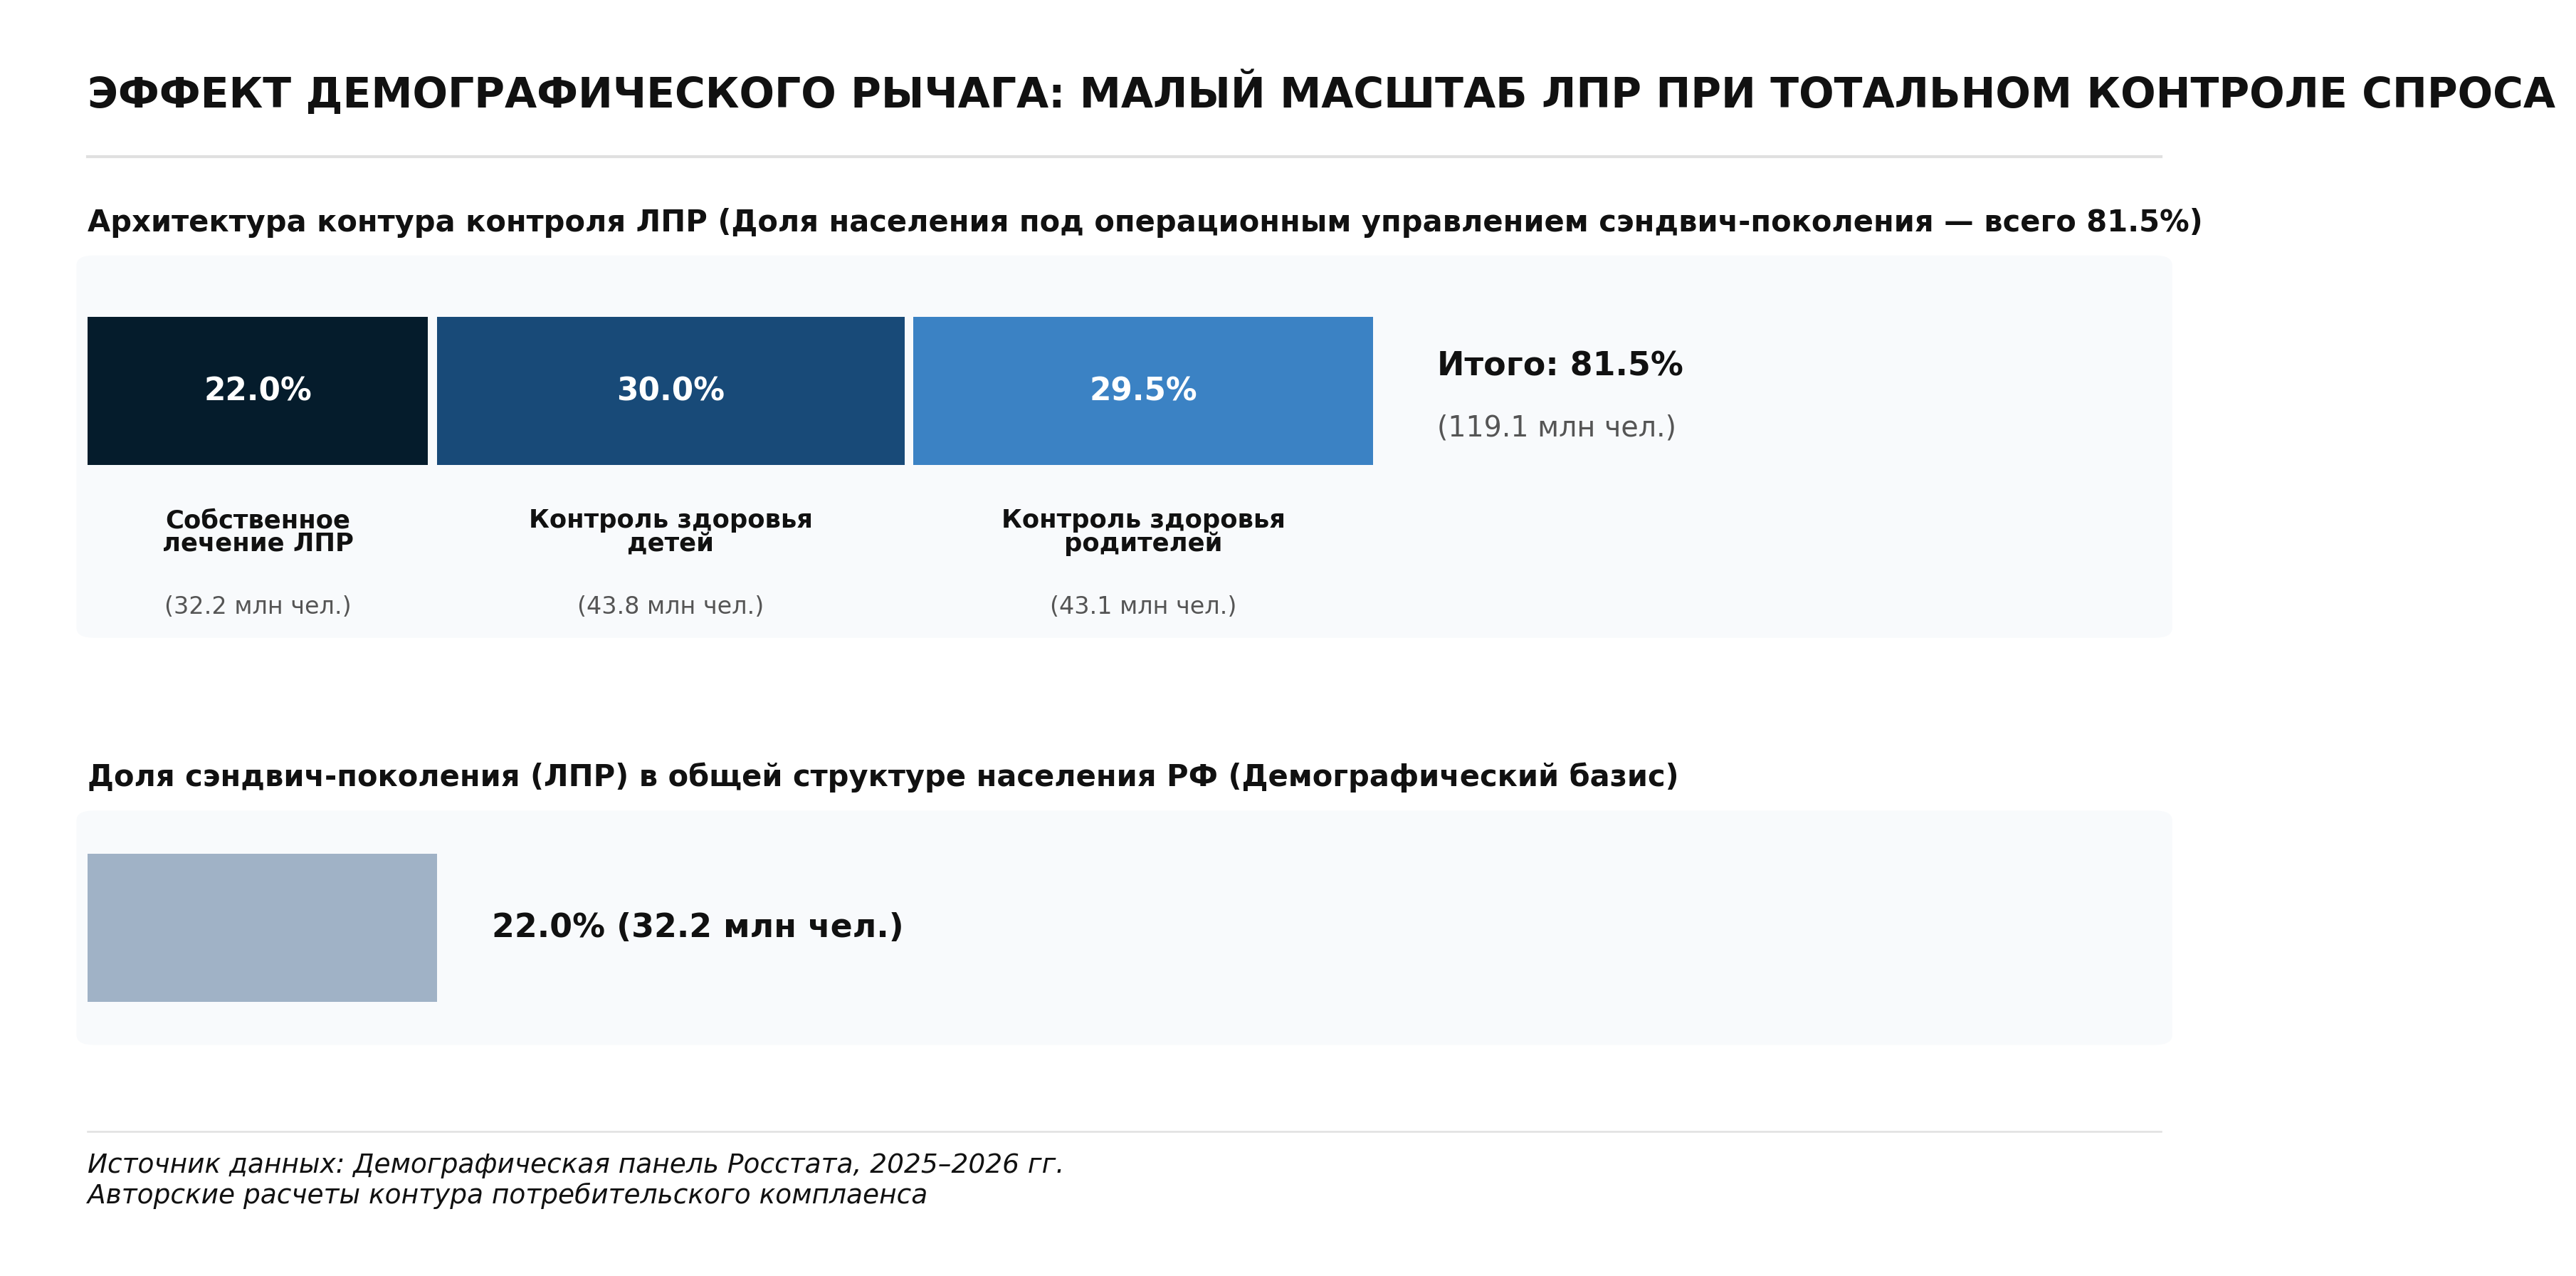

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Настройка холста (16:9, высокое разрешение)
fig, ax = plt.subplots(figsize=(13.33, 7.5), dpi=300)
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')
ax.axis('off')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# Цветовая гамма McKinsey
COLOR_PRIMARY = '#051C2C'   # Темно-синий
COLOR_BLUE_1  = '#184A78'   # Насыщенный синий
COLOR_BLUE_2  = '#3B82C4'   # Голубой
COLOR_LIGHT   = '#A0B2C6'   # Серо-голубой фоновый
GRAY_TEXT     = '#111111'
GRAY_SUB      = '#555555'
GRAY_LINE     = '#E0E0E0'
GRAY_BG       = '#F8FAFC'

# --- ЗАГОЛОВОК СЛАЙДА ---
ax.text(3, 93, "ЭФФЕКТ ДЕМОГРАФИЧЕСКОГО РЫЧАГА: МАЛЫЙ МАСШТАБ ЛПР ПРИ ТОТАЛЬНОМ КОНТРОЛЕ СПРОСА",
        fontsize=14, fontweight='bold', color=GRAY_TEXT, family='sans-serif')

ax.plot([3, 97], [89, 89], color=GRAY_LINE, linewidth=1.0)

# ==========================================
# ЧАСТЬ 1: АРХИТЕКТУРА КОНТУРА КОНТРОЛЯ ЛПР
# ==========================================
ax.text(3, 83, "Архитектура контура контроля ЛПР (Доля населения под операционным управлением сэндвич-поколения — всего 81.5%)",
        fontsize=10.0, fontweight='bold', color=GRAY_TEXT)

# Данные из 3 сегментов
stacked_data = [
    {
        "title": "Собственное\nлечение ЛПР",
        "abs": "(32.2 млн чел.)",
        "val": 22.0,
        "color": COLOR_PRIMARY
    },
    {
        "title": "Контроль здоровья\nдетей",
        "abs": "(43.8 млн чел.)",
        "val": 30.0,
        "color": COLOR_BLUE_1
    },
    {
        "title": "Контроль здоровья\nродителей",
        "abs": "(43.1 млн чел.)",
        "val": 29.5,
        "color": COLOR_BLUE_2
    }
]

y_top = 64.0
bar_h = 12.0
x_start = 3.0
total_max_w = 72.0  # Ширина под шкалу полос

# Фоновый контейнер под верхний блок
bg_card1 = patches.FancyBboxPatch(
    (2.5, 50.0), 95.0, 31.0, boxstyle="round,pad=0.0,rounding_size=0.8",
    facecolor=GRAY_BG, edgecolor='none'
)
ax.add_patch(bg_card1)

for seg in stacked_data:
    seg_w = (seg["val"] / 100.0) * total_max_w

    # Сегмент полосы
    rect = patches.Rectangle((x_start, y_top), seg_w - 0.4, bar_h, facecolor=seg["color"], edgecolor='none')
    ax.add_patch(rect)

    # Процент
    ax.text(x_start + seg_w / 2.0 - 0.2, y_top + bar_h / 2.0, f"{seg['val']:.1f}%",
            fontsize=10.5, fontweight='bold', color='#FFFFFF', ha='center', va='center')

    # Подпись под сегментом
    ax.text(x_start + seg_w / 2.0 - 0.2, y_top - 3.5, seg["title"],
            fontsize=8.5, fontweight='bold', color=GRAY_TEXT, ha='center', va='top', linespacing=0.95)
    ax.text(x_start + seg_w / 2.0 - 0.2, y_top - 10.5, seg["abs"],
            fontsize=8.0, color=GRAY_SUB, ha='center', va='top')

    x_start += seg_w

# Итоговый блок справа
ax.text(x_start + 2.5, y_top + bar_h / 2.0 + 2.0, "Итого: 81.5%",
        fontsize=11, fontweight='bold', color=GRAY_TEXT, va='center')
ax.text(x_start + 2.5, y_top + bar_h / 2.0 - 3.0, "(119.1 млн чел.)",
        fontsize=9.5, color=GRAY_SUB, va='center')


# ==========================================
# ЧАСТЬ 2: ДОЛЯ СЭНДВИЧ-ПОКОЛЕНИЯ
# ==========================================
ax.text(3, 38, "Доля сэндвич-поколения (ЛПР) в общей структуре населения РФ (Демографический базис)",
        fontsize=10.0, fontweight='bold', color=GRAY_TEXT)

# Фоновый контейнер под нижний блок
bg_card2 = patches.FancyBboxPatch(
    (2.5, 17.0), 95.0, 19.0, boxstyle="round,pad=0.0,rounding_size=0.8",
    facecolor=GRAY_BG, edgecolor='none'
)
ax.add_patch(bg_card2)

y_bot = 20.5
bot_w = (22.0 / 100.0) * total_max_w

# Одиночная полоса
rect_bot = patches.Rectangle((3.0, y_bot), bot_w, bar_h, facecolor=COLOR_LIGHT, edgecolor='none')
ax.add_patch(rect_bot)

# Текст справа от полосы
ax.text(3.0 + bot_w + 2.5, y_bot + bar_h / 2.0, "22.0% (32.2 млн чел.)",
        fontsize=11, fontweight='bold', color=GRAY_TEXT, va='center')


# ==========================================
# ПОДВАЛ И СНОСКИ
# ==========================================
ax.plot([3, 97], [10, 10], color=GRAY_LINE, linewidth=0.6)

ax.text(3, 6.0, "Источник данных: Демографическая панель Росстата, 2025–2026 гг.\nАвторские расчеты контура потребительского комплаенса", fontsize=9, color='#111111', fontweight='normal', style='italic', va='center', family='sans-serif')

# 3. Фиксация нижней границы холста, чтобы обрезка не задевала текст
ax.plot([0, 100], [0, 0], alpha=0)

# Сохранение изображения
plt.savefig('demographic_leverage_updated.png', dpi=300, bbox_inches='tight')
plt.show()